In [3]:
print("Hello")

Hello


In [1]:
from langchain_groq import ChatGroq
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import create_react_agent
from langgraph.store.memory import InMemoryStore
from langgraph.utils.config import get_store
from langmem import create_manage_memory_tool

In [24]:
def prompt(state):
    store = get_store()
    memories = store.search(
        ("memories",),
        query=state["messages"][-1].content,
    )
    system_msg = f"""You are a helpful assistant.
## Memories
<memories>
{memories}
</memories>
"""
    return [{"role": "system", "content": system_msg}, *state["messages"]]

In [ ]:
embeddings = GoogleGenerativeAIEmbeddings(
    model="gemini-embedding-001",
    google_api_key="",
)

In [ ]:
llm = ChatGroq(
    model="qwen/qwen3-32b",
    groq_api_key="",
    temperature=0,
)

In [27]:
store = InMemoryStore(
    index={
        "embed": embeddings,
        "dims": 3072,
    }
)

In [28]:
checkpointer = MemorySaver()

In [35]:
agent = create_react_agent(
    llm,
    prompt=prompt,
    tools=[create_manage_memory_tool(namespace=("memories",))],
    store=store,
    checkpointer=checkpointer,
)

C:\Users\M326929\AppData\Local\Temp\ipykernel_1976\1255034601.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(


In [13]:
config = {"configurable": {"thread_id": "thread-a"}}

In [15]:
response = agent.invoke(
    {
        "messages": [
            {"role": "user", "content": "Know which display mode I prefer?"}
        ]
    },
    config=config,
)
print(response["messages"][-1].content)

I don't currently have information about your preferred display mode stored in my memory. Would you like to specify your preferred display mode (e.g., "dark mode," "light mode," "high contrast") so I can create a memory for future interactions?


In [16]:
agent.invoke(
    {
        "messages": [
            {"role": "user", "content": "I prefer dark mode. Remember that."}
        ]
    },
    config=config,
)

NumPy not found in the current Python environment. The InMemoryStore will use a pure Python implementation for vector operations, which may significantly impact performance, especially for large datasets or frequent searches. For optimal speed and efficiency, consider installing NumPy: pip install numpy


{'messages': [HumanMessage(content='Know which mode I prefer?', additional_kwargs={}, response_metadata={}, id='2998e602-6698-4140-94eb-d65a16b41f1c'),
  AIMessage(content='I don\'t currently have information about your preferred mode stored in my memory. Would you like to specify your preferred interaction style (e.g., "casual conversation" or "formal discussion") so I can create a memory for future reference?', additional_kwargs={'reasoning_content': "Okay, the user is asking if I know which mode they prefer. Let me check my memories first. The memories section is empty, so there's no stored information about their preferences.\n\nSince there's no existing memory, I need to respond that I don't have that information. But maybe the user wants me to remember their preference in the future. I should offer to create a memory if they tell me their preferred mode. That way, I can store it and use it in future interactions. I'll mention the available modes, like casual or formal, and ask th

In [17]:
new_config = {"configurable": {"thread_id": "thread-b"}}

In [21]:
response = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Hey there. Do you remember me? What are my preferences?"
            }
        ]
    },
    config=new_config,
)

print(response["messages"][-1].content)

I remember you! Based on our previous conversation, I know that you prefer dark mode for display. Is there anything else you'd like me to remember or adjust for you?


In [22]:
all_memories = store.search(
    ("memories",),
    limit=100,
)

for m in all_memories:
    print("namespace:", m.namespace)
    print("key:", m.key)
    print("value:", m.value)
    print("---")

namespace: ('memories',)
key: e57eea02-1154-491f-8a6c-408ac1bd71f1
value: {'content': 'User prefers dark mode for display.'}
---


In [3]:
from langchain_groq import ChatGroq

In [2]:
import os
from dotenv import load_dotenv

In [3]:
load_dotenv()

True

In [4]:
from langchain_groq import ChatGroq

llm_groq = ChatGroq(model="llama-3.1-8b-instant", temperature=0, max_tokens=200)

llm_groq.invoke("Hello")

AIMessage(content='Hello. How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 36, 'total_tokens': 46, 'completion_time': 0.01201638, 'completion_tokens_details': None, 'prompt_time': 0.001655615, 'prompt_tokens_details': None, 'queue_time': 0.052091745, 'total_time': 0.013671995}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dedcf-c76e-7bd2-a55b-8729e99fab07-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 10, 'total_tokens': 46})

In [5]:
from langchain.tools import tool
from langchain.agents import create_agent



In [6]:
import requests

@tool("Weather_tool", description="Fetches current weather details for a specified location. Use it for weather-related questions like temperature, rain, humidity, wind, or forecast.")
def get_weather(city: str)-> dict:
    """Get the current weather for a given city"""
    try:
        geo_url=f"https://geocoding-api.open-meteo.com/v1/search?name={city}&count=1&language=en&format=json"
        geo_data = requests.get(geo_url).json()

        if not geo_data.get("results"):
            return {"error": f"City '{city}' not found"}
        
        location = geo_data["results"][0]
        lat, lon = location["latitude"], location['longitude']

        weather_url = f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}&current=temperature_2m,weather_code"
        date = requests.get(weather_url).json()

        temp = date["current"]["temperature_2m"]
        return {"city":city, "temp":temp, "unit":"C"}





    except Exception as e:
        return {"error":str(e)}


In [7]:
all_tools = [get_weather]

In [8]:
agent = create_agent(model=llm_groq, tools=all_tools)

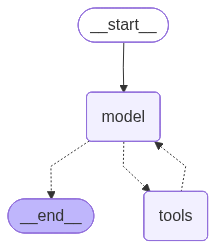

In [9]:
agent

In [10]:
query = "check the weather of bengaluru"

response = agent.invoke({"messages": [("user", query)]})

response

{'messages': [HumanMessage(content='check the weather of bengaluru', additional_kwargs={}, response_metadata={}, id='30d4d968-16c6-4cc7-ad32-091cd49b7aad'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'dxbjqq8rh', 'function': {'arguments': '{"city":"Bengaluru"}', 'name': 'Weather_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 262, 'total_tokens': 280, 'completion_time': 0.027533456, 'completion_tokens_details': None, 'prompt_time': 0.019008999, 'prompt_tokens_details': None, 'queue_time': 0.053232361, 'total_time': 0.046542455}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dedd0-19c4-7c71-b71f-dfe6ef6ad2fa-0', tool_calls=[{'name': 'Weather_tool', 'args': {'city': 'Bengaluru'}, 'id': 'dxbjqq8rh', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata=